In [1]:
import os, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Torchvision is required for CIFAR-10 and VGG-11
import torchvision
import torchvision.transforms as T
from torchvision.models import vgg11, VGG11_Weights

# Reproducibility
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## Data: CIFAR-10 + normalization

For pretrained ImageNet models, ImageNet normalization is a common choice:

- mean = (0.485, 0.456, 0.406)
- std  = (0.229, 0.224, 0.225)

We keep CIFAR-10 at 32×32 (no resize).  
If you want to resize to 224×224, add `T.Resize(224)` before `ToTensor()`.


In [2]:
# Transforms
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std  = (0.229, 0.224, 0.225)

transform = T.Compose([
    # T.Resize(224),  # optional
    T.ToTensor(),
    T.Normalize(imagenet_mean, imagenet_std),
])

# Datasets
train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_set   = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

# Validation split from training set
val_size = 5000
train_size = len(train_full) - val_size
train_set, val_set = random_split(train_full, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(seed))

batch_size = 256
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("train/val/test sizes:", len(train_set), len(val_set), len(test_set))

100%|██████████| 170M/170M [00:05<00:00, 30.1MB/s]


train/val/test sizes: 45000 5000 10000


## Model 1: MLP baseline (from scratch)

A simple MLP that flattens 32×32×3 into a vector.


In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*32*3, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        return self.net(x)

mlp = MLP().to(device)
print("MLP params:", sum(p.numel() for p in mlp.parameters()))

MLP params: 3676682


## Models 2 & 3: VGG-11 pretrained (ImageNet)

We load pretrained VGG-11 and replace its classifier with a CIFAR-10 head.

To make VGG-11 compatible with 32×32 inputs, we set:
- `model.avgpool = AdaptiveAvgPool2d((1,1))`
- `classifier = Linear(512 -> 256) -> ReLU -> Dropout -> Linear(256 -> 10)`

### Frozen vs Fine-tuned
- **Frozen**: `requires_grad=False` for `model.features` parameters
- **Fine-tuned**: all parameters trainable


In [4]:
def make_vgg11_cifar10(freeze_features: bool):
    model = vgg11(weights=VGG11_Weights.IMAGENET1K_V1)

    # Make it work nicely on 32x32 by pooling to 1x1
    model.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    # Replace classifier
    model.classifier = nn.Sequential(
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(256, 10)
    )

    if freeze_features:
        for p in model.features.parameters():
            p.requires_grad = False

    return model.to(device)

vgg_frozen = make_vgg11_cifar10(freeze_features=True)
vgg_ft     = make_vgg11_cifar10(freeze_features=False)

print("VGG frozen trainable params:",
      sum(p.numel() for p in vgg_frozen.parameters() if p.requires_grad))
print("VGG fine-tune trainable params:",
      sum(p.numel() for p in vgg_ft.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/vgg11-8a719046.pth" to /root/.cache/torch/hub/checkpoints/vgg11-8a719046.pth


100%|██████████| 507M/507M [00:06<00:00, 79.7MB/s]


VGG frozen trainable params: 133898
VGG fine-tune trainable params: 9354378


In [5]:
def evaluate_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return correct / total

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

    train_losses, val_accs = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, n_seen = 0.0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * yb.size(0)
            n_seen += yb.size(0)

        avg_loss = running_loss / n_seen
        val_acc = evaluate_accuracy(model, val_loader)

        train_losses.append(avg_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} | train loss={avg_loss:.4f} | val acc={val_acc:.4f}")

    return train_losses, val_accs

## Run experiments (10 epochs)

You can adjust learning rates below if needed.
Typical starting points:
- MLP: 1e-3
- Frozen VGG: 1e-3 (only head training)
- Fine-tuned VGG: 1e-4 or 1e-5 (more conservative)


In [6]:
EPOCHS = 10

# 1) MLP baseline
mlp = MLP().to(device)
mlp_loss, mlp_acc = train_model(mlp, train_loader, val_loader, epochs=EPOCHS, lr=1e-3)

# 2) Frozen VGG-11
vgg_frozen = make_vgg11_cifar10(freeze_features=True)
fro_loss, fro_acc = train_model(vgg_frozen, train_loader, val_loader, epochs=EPOCHS, lr=1e-3)

# 3) Fine-tuned VGG-11
vgg_ft = make_vgg11_cifar10(freeze_features=False)
ft_loss, ft_acc = train_model(vgg_ft, train_loader, val_loader, epochs=EPOCHS, lr=1e-4)

print("Done.")

Epoch 01/10 | train loss=1.6600 | val acc=0.4572
Epoch 02/10 | train loss=1.4305 | val acc=0.4704
Epoch 03/10 | train loss=1.3124 | val acc=0.5068
Epoch 04/10 | train loss=1.2183 | val acc=0.5062
Epoch 05/10 | train loss=1.1339 | val acc=0.4966
Epoch 06/10 | train loss=1.0449 | val acc=0.5250
Epoch 07/10 | train loss=0.9658 | val acc=0.5248
Epoch 08/10 | train loss=0.8870 | val acc=0.5214
Epoch 09/10 | train loss=0.8070 | val acc=0.5124
Epoch 10/10 | train loss=0.7413 | val acc=0.5318
Epoch 01/10 | train loss=1.1371 | val acc=0.6854
Epoch 02/10 | train loss=0.9179 | val acc=0.6980
Epoch 03/10 | train loss=0.8611 | val acc=0.7078
Epoch 04/10 | train loss=0.8220 | val acc=0.7152
Epoch 05/10 | train loss=0.7907 | val acc=0.7186
Epoch 06/10 | train loss=0.7687 | val acc=0.7134
Epoch 07/10 | train loss=0.7397 | val acc=0.7238
Epoch 08/10 | train loss=0.7223 | val acc=0.7188
Epoch 09/10 | train loss=0.7025 | val acc=0.7210
Epoch 10/10 | train loss=0.6812 | val acc=0.7136
Epoch 01/10 | train 

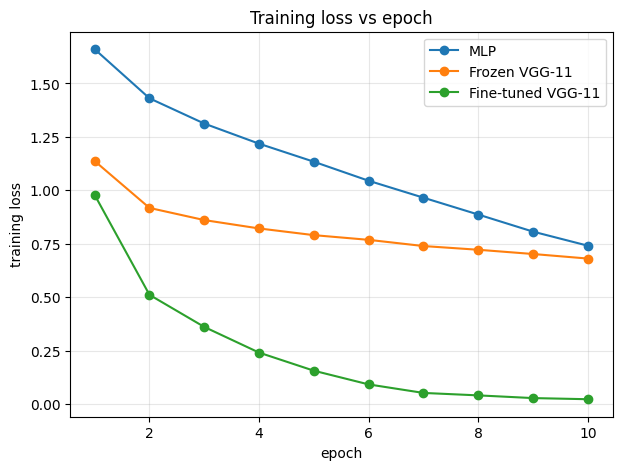

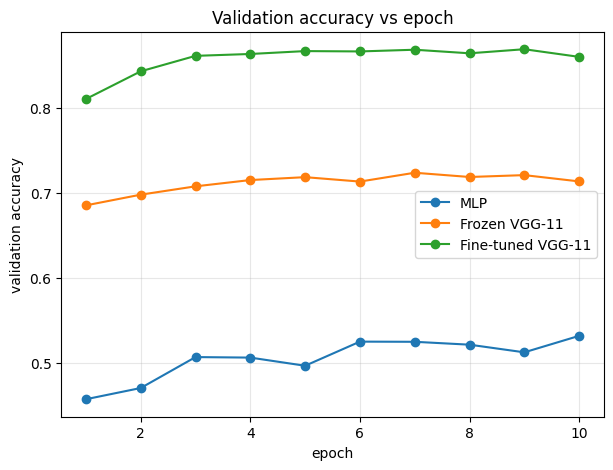

In [7]:
epochs = list(range(1, EPOCHS + 1))

plt.figure(figsize=(7,5))
plt.plot(epochs, mlp_loss, marker="o", label="MLP")
plt.plot(epochs, fro_loss, marker="o", label="Frozen VGG-11")
plt.plot(epochs, ft_loss,  marker="o", label="Fine-tuned VGG-11")
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("Training loss vs epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, mlp_acc, marker="o", label="MLP")
plt.plot(epochs, fro_acc, marker="o", label="Frozen VGG-11")
plt.plot(epochs, ft_acc,  marker="o", label="Fine-tuned VGG-11")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("Validation accuracy vs epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
mlp_test = evaluate_accuracy(mlp, test_loader)
fro_test = evaluate_accuracy(vgg_frozen, test_loader)
ft_test  = evaluate_accuracy(vgg_ft, test_loader)

print(f"Test accuracy | MLP: {mlp_test:.4f} | Frozen VGG: {fro_test:.4f} | Fine-tuned VGG: {ft_test:.4f}")

Test accuracy | MLP: 0.5333 | Frozen VGG: 0.7158 | Fine-tuned VGG: 0.8582
